# Benchmark: PXD014777 HeLa 10 replicate dataset

This notebook contains code to benchmark the PIPP model on [PXD014777 dataset](https://proteomecentral.proteomexchange.org/cgi/GetDataset?ID=PXD014777) - HeLa10replicates2h-1.0.10.4_MaxQuant.txt.zip. Here, we'll use two txt files from the dataset:

- allPeptides.txt: All the peptides with MS-1 data
- evidence.txt: A subset of the peptides in allPeptides.txt, which contains both MS-1 and MS-2 data

We'll use PIPP to compute the embeddings of each MS-1 datapoint. Followed by peptide identity propagation using the MS1/MS2 data as the support data.

Let's start with the imports.

In [1]:
%%capture

%matplotlib inline
%load_ext autoreload
%autoreload 2

from collections import defaultdict
import re
import os

import pandas as pd
import umap
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

import pipp
import pipp.utils

np.random.seed(0)

Let's define the paths to the data and the pretrained model.

In [2]:
PEPTIDES_PATH = "../../data/HeLa10replicates/txt/allPeptides.txt"
EVIDENCE_PATH = "../../data/txt/HeLa10replicates/evidence.txt"
EVIDENCE_MAPPED_PATH = "../../data/HeLa10replicates/txt/evidence_mapped.txt" # @NOTE: file is auto-generated if it doesn't exist

PRETRAINED_MODEL_PATH = "../../data/PXD019086_PXD010012_combined_evidence_90Kto20Ksplit_5query_1shot_fullmodel_featuresScaled_allPeptidesTxtFeatures_modSeqSpecies_hidden64_latent10_maxEpoch300_164trainways_xlatent_conditionalEmbedding.pth"

## Data Preparation

Let's load and clean the data.

In [3]:
ms1_raw_data = pd.read_csv(PEPTIDES_PATH, sep='\t', header=0)

As mentioned in the introduction, the MS2 data is a subset of the MS1 data (with additional features). However, it is not trivial to map the MS2 data back to the MS1 data, due to small differences in feature values. Hence, we can't just compare the features: ['Raw file', 'Charge', 'm/z', 'Mass', 'Intensity', 'Retention time'].
Instead we'll compute a mapping here as we'll later need to know which entries in the MS1 data corresponds to the MS2 data. The indices in MS2 data will match those in MS1 data - after performing the "mapping".

In [4]:
if not os.path.isfile(EVIDENCE_MAPPED_PATH):
    ms2_raw_data = pd.read_csv(EVIDENCE_PATH, sep='\t', header=0, low_memory=False)
    ms2_raw_data = pipp.utils.link_MSMS_to_MS(ms2_raw_data, ms1_raw_data, verbose=True)
    ms2_raw_data.to_csv(EVIDENCE_MAPPED_PATH, sep='\t', index=True)

In [5]:
ms2_raw_data = pd.read_csv(EVIDENCE_MAPPED_PATH, sep='\t', header=0, low_memory=False, index_col=0)

Let's look at the dimensions of the data.

In [6]:
print('MS1 data shape:     {}'.format(ms1_raw_data.shape))
print('MS1+MS2 data shape: {}'.format(ms2_raw_data.shape))

MS1 data shape:     (4101555, 24)
MS1+MS2 data shape: (634466, 70)


### MS1 data preprocessing

Let's look at the features available in the MS1 data:

In [7]:
ms1_raw_data.columns.unique()

Index(['Raw file', 'Charge', 'm/z', 'Mass', 'Resolution',
       'Number of data points', 'Number of frames', 'Number of isotopic peaks',
       'Isotope correlation', 'Mass fractional part', 'Mass deficit',
       'Retention time', 'Retention length', 'Retention length (FWHM)',
       'Min frame index', 'Max frame index', 'Ion mobility index',
       'Ion mobility index length', 'Ion mobility index length (FWHM)',
       'Intensity', 'Intensities', 'Number of pasef MS/MS', 'Pasef MS/MS IDs',
       'MS/MS scan number'],
      dtype='object')

Let's filter out low quality peptides.

In [8]:
# filter out low quality peptides
ms1_data = ms1_raw_data.loc[(ms1_raw_data['Charge'] != 1) & (ms1_raw_data['Intensity'] > 0)]

In [9]:
ms1_raw_peptides_per_run = [np.sum(ms1_raw_data['Raw file'] == run) for run in ms1_raw_data['Raw file'].unique()]
ms1_peptides_per_run = [np.sum(ms1_data['Raw file'] == run) for run in ms1_data['Raw file'].unique()]

Text(0, 0.5, 'Number of peptides')

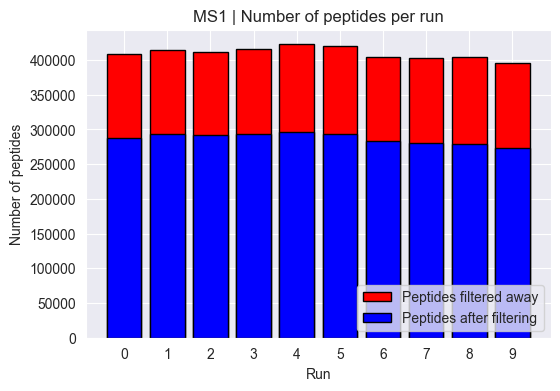

In [10]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(range(len(ms1_raw_peptides_per_run)), ms1_raw_peptides_per_run, color='red', edgecolor='black')
ax.bar(range(len(ms1_peptides_per_run)), ms1_peptides_per_run, color='blue', edgecolor='black')
ax.legend(['Peptides filtered away', 'Peptides after filtering'], loc='lower right')

ax.grid(True)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(0, len(ms1_raw_peptides_per_run), 1))
ax.set_title("MS1 | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [11]:
print(f"After filtering | MS1 data points: {ms1_data.shape[0]} ({ms1_data.shape[0] / ms1_raw_data.shape[0] * 100:.2f}%)")

After filtering | MS1 data points: 2871496 (70.01%)


### MS2 (MSMS) data preprocessing

Let's look at the features available in the MS2 data:

In [12]:
ms2_raw_data.columns.unique()

Index(['Sequence', 'Length', 'Modifications', 'Modified sequence',
       'Oxidation (M) Probabilities', 'Oxidation (M) Score Diffs',
       'Acetyl (Protein N-term)', 'Oxidation (M)', 'Missed cleavages',
       'Proteins', 'Leading proteins', 'Leading razor protein', 'Gene names',
       'Protein names', 'Type', 'Raw file', 'Experiment', 'MS/MS m/z',
       'Charge', 'm/z', 'Mass', 'Resolution',
       'Uncalibrated - Calibrated m/z [ppm]',
       'Uncalibrated - Calibrated m/z [Da]', 'Mass error [ppm]',
       'Mass error [Da]', 'Uncalibrated mass error [ppm]',
       'Uncalibrated mass error [Da]', 'Max intensity m/z 0', 'Retention time',
       'Retention length', 'Calibrated retention time',
       'Calibrated retention time start', 'Calibrated retention time finish',
       'Retention time calibration', 'Ion mobility index',
       'Ion mobility length', '1/K0', '1/K0 length', 'Calibrated 1/K0', 'CCS',
       'CCS length', 'Match time difference', 'Match m/z difference',
       '

Let's filter out low quality peptides.

In [13]:
# filter out low quality peptides
ms2_data = ms2_raw_data.loc[(ms2_raw_data['Charge'] != 1) & (ms2_raw_data['Intensity'] > 0)]

# keep the most intense peptides
ms2_data = ms2_data.loc[ms2_data.groupby(['Modified sequence', 'Charge', 'Raw file'])['Intensity'].idxmax()]

# remove contaminants
ms2_data = ms2_data.loc[[(not bool(re.search('CON__|REV__', i))) for i in ms2_data['Leading razor protein'].tolist()]]

# define identifier for each peptide
ms2_data['PrecursorID'] = ms2_data['Modified sequence'].astype(str).str.cat(ms2_data['Charge'].astype(str), sep='')

In [14]:
ms2_raw_peptides_per_run = [np.sum(ms2_raw_data['Raw file'] == run) for run in ms2_raw_data['Raw file'].unique()]
ms2_peptides_per_run = [np.sum(ms2_data['Raw file'] == run) for run in ms2_data['Raw file'].unique()]

Text(0, 0.5, 'Number of peptides')

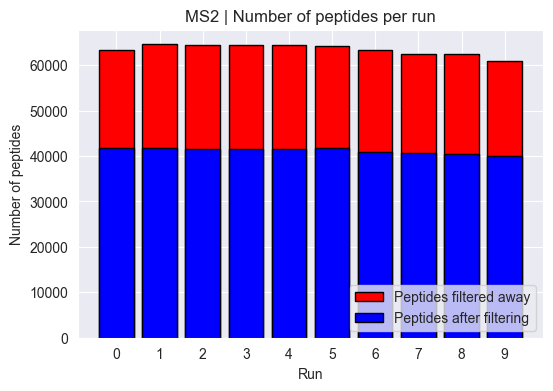

In [15]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.bar(range(len(ms2_raw_peptides_per_run)), ms2_raw_peptides_per_run, color='red', edgecolor='black')
ax.bar(range(len(ms2_peptides_per_run)), ms2_peptides_per_run, color='blue', edgecolor='black')
ax.legend(['Peptides filtered away', 'Peptides after filtering'], loc='lower right')

ax.grid(True)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(0, len(ms2_raw_peptides_per_run), 1))
ax.set_title("MS2 | Number of peptides per run")
ax.set_xlabel("Run")
ax.set_ylabel("Number of peptides")

In [16]:
print(f"After filtering | MS2 data points: {ms2_data.shape[0]} ({ms2_data.shape[0] / ms2_raw_data.shape[0] * 100:.2f}%)")

After filtering | MS2 data points: 411838 (64.91%)


Let's see how many runs a peptide is present in.

In [17]:
peptide_abundances = ms2_data['PrecursorID'].value_counts()

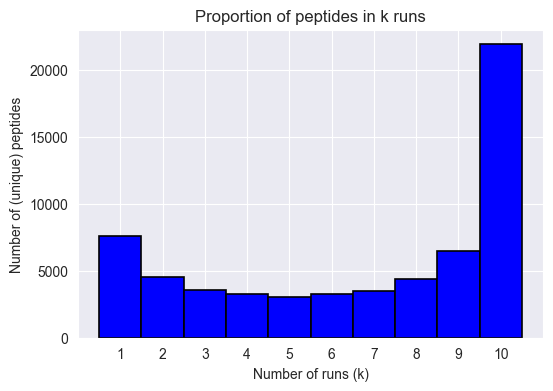

In [18]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.hist(peptide_abundances, bins=range(1, np.max(peptide_abundances)+2), color='blue', edgecolor='black', linewidth=1.2, align='left')
ax.set_xticks(range(1, np.max(peptide_abundances)+1))
ax.set_title('Proportion of peptides in k runs')
ax.set_xlabel('Number of runs (k)')
ax.set_ylabel('Number of (unique) peptides')
ax.grid(True)
ax.set_axisbelow(True)

### Feature Extraction

Let's extract the features which the model takes as input.

It seems like the two datasets use a different name for 'Ion mobilility index length' / 'Ion mobility length'. Let's rename one of them to be consistent between the datasets.

In [19]:
ms1_data = ms1_data.copy()
ms1_data.rename(columns={'Ion mobility index length': 'Ion mobility length'}, inplace=True)

In [20]:
features = ['Charge', 'Mass', 'm/z', 'Retention time','Retention length', 'Ion mobility index', 'Ion mobility length','Number of isotopic peaks']

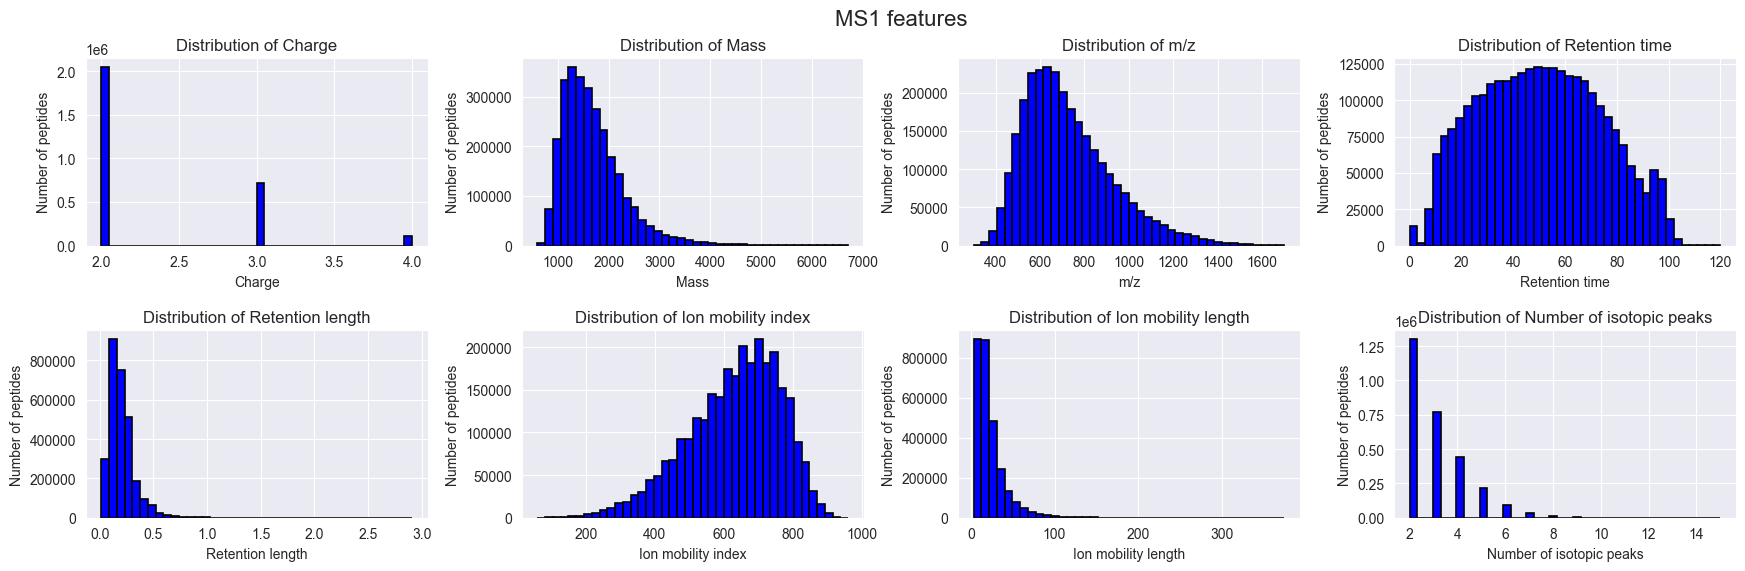

In [21]:
fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle('MS1 features', fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(ms1_data[feature], bins=40, color='blue', edgecolor='black', linewidth=1.2)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of peptides')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(True)
    ax.set_axisbelow(True)

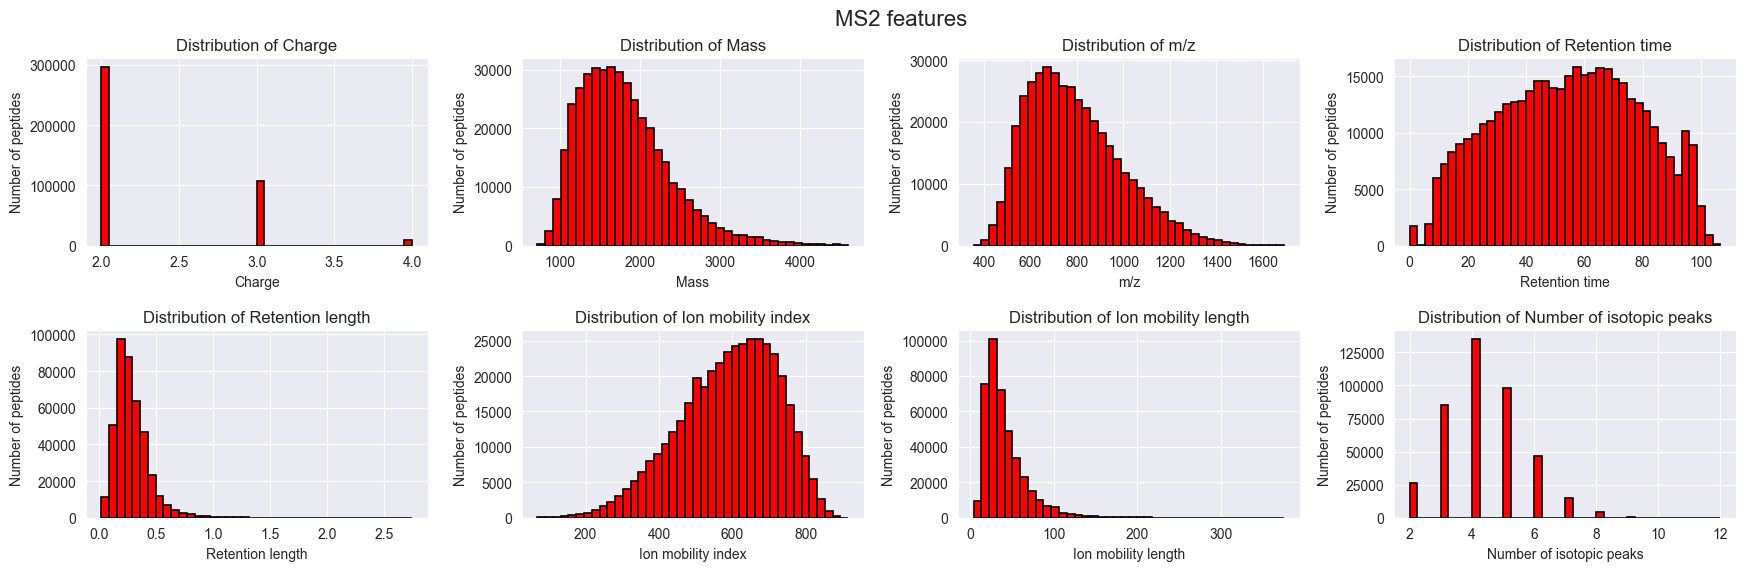

In [22]:
fig, axs = plt.subplots(figsize=(18, 6), ncols=4, nrows=2)
fig.tight_layout(pad=4.0)
fig.suptitle('MS2 features', fontsize=16)

for i, feature in enumerate(features):
    ax = axs[i // 4][i % 4]
    ax.hist(ms2_data[feature], bins=40, color='red', edgecolor='black', linewidth=1.2)
    ax.set_xlabel(feature)
    ax.set_ylabel('Number of peptides')
    ax.set_title(f'Distribution of {feature}')
    ax.grid(True)
    ax.set_axisbelow(True)

In [23]:
ms1_features = ms1_data[features]
ms2_features = ms2_data[features]

## PIPP model

### Computing the Embeddings

Let's load the model and compute the embeddings.

In [24]:
model = pipp.Peptideprotonet.load(PRETRAINED_MODEL_PATH)

In [25]:
ms1_embeddings = model.get_latent_representations(ms1_features)

In [26]:
ms2_embeddings = model.get_latent_representations(ms2_features)

In [27]:
ms1_embeddings = ms1_embeddings - np.mean(ms1_embeddings, axis=0)
ms2_embeddings = ms2_embeddings - np.mean(ms2_embeddings, axis=0)

Let's look at the embedding space.
We'll look at a subset of peptides due to memory limitations.

In [28]:
n = 50_000
random_indices = np.random.choice(range(len(ms2_embeddings)), size=n, replace=False)

Let's also add some "random" peptides to ensure all possible runs of at least a few peptides are included.

In [29]:
high_coverage_peptides_to_include = [
    '_(ac)AAAAAAAAAAGAAGGR_2',
    '_LGMENDDTAVQYAIGR_2',
    '_LGHVVMGNNAVSPYQQVIEK_2',
    '_LEEVLSTEGAEENGNSDK_2',
    '_PAPQMNGSTGDAR_2',
    '_HLQINQTFEELR_2',
    '_LLAGEDGTSER_2',
    '_LETMPLYLEDDIRPDIK_3',
    '_LFNDSSPVVLEESWDALNAITK_3',
]

low_coverage_peptides_to_include = [
    '_ELFEQYGAVYEINVLR_3',
    '_ELFDELVK_2',
    '_FLGDYVENLNK_2',
    '_HHSQQAPQAEAPCLLR_3',
    '_HFSTTTNNIQSR_2',
    '_LEEIAELVASSLPSPLR_3',
    '_AVLEQFGFPLTGTEAR_2',
    '_VPQFSFLDIFPK_2',
    '_VGPYHNPQETYHYYQLPVCCPEK_3',
    '_FDSASSSYYLDMHSLPHVINPVESR_4',
]

peptides_to_include = high_coverage_peptides_to_include + low_coverage_peptides_to_include

custom_indices = [ms2_data.index[ms2_data['PrecursorID'] == peptide].tolist() for peptide in peptides_to_include]
custom_indices = [peptide for peptide_runs in custom_indices for peptide in peptide_runs]
custom_indices = [ms2_data.index.get_loc(i) for i in custom_indices]

# print(peptides_abundances)

In [30]:
indices = np.unique(np.concatenate((random_indices, custom_indices)))

In [31]:
ms2_data_subset = ms2_data.iloc[indices]
ms2_embeddings_subset = ms2_embeddings[indices]

Let's compute the UMAP for plotting.

In [32]:
# reducer = umap.UMAP(metric = 'cosine')
# umap_embedding = reducer.fit_transform(ms2_embeddings_subset)

In [33]:
'''fig, axs = plt.subplots(figsize=(14, 12), ncols=2, nrows=2)

ax = axs[0][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['Retention time'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - RT')
fig.colorbar(sp)

ax = axs[0][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['Charge'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Charge')
fig.colorbar(sp)

ax = axs[1][0]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['Mass'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - Mass')
fig.colorbar(sp)

ax = axs[1][1]
sp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['m/z'], s=0.1)
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - m/z')
fig.colorbar(sp)
'''

"fig, axs = plt.subplots(figsize=(14, 12), ncols=2, nrows=2)\n\nax = axs[0][0]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['Retention time'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - RT')\nfig.colorbar(sp)\n\nax = axs[0][1]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['Charge'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - Charge')\nfig.colorbar(sp)\n\nax = axs[1][0]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['Mass'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - Mass')\nfig.colorbar(sp)\n\nax = axs[1][1]\nsp = ax.scatter(umap_embedding[:,0], umap_embedding[:,1], c=ms2_data_subset['m/z'], s=0.1)\nax.set_xlabel('UMAP1')\nax.set_ylabel('UMAP2')\nax.set_title('MS2 | latent space - m/z')\nfig.colorbar(sp)\n"

Let's also plot the latent space of the MS2 data together with some low coverage and high coverage peptides.

In [34]:
'''
fig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)
fig.tight_layout(pad=4.0)

# high coverage peptides
ax = axs[0]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(high_coverage_peptides_to_include):
    peptide_ref_indices = np.where(ms2_data_subset['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - high coverage peptides')

# low coverage peptides
ax = axs[1]
ax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color='lightgrey')

for i, peptide in enumerate(low_coverage_peptides_to_include):
    peptide_ref_indices = np.where(ms2_data_subset['PrecursorID'] == peptide)
    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")

ax.legend(markerscale=3, loc='upper center', bbox_to_anchor=(0.5, -0.1))
ax.set_xlabel('UMAP1')
ax.set_ylabel('UMAP2')
ax.set_title('MS2 | latent space - low coverage peptides')
'''

'\nfig, axs = plt.subplots(figsize=(12, 6), ncols=2, nrows=1)\nfig.tight_layout(pad=4.0)\n\n# high coverage peptides\nax = axs[0]\nax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color=\'lightgrey\')\n\nfor i, peptide in enumerate(high_coverage_peptides_to_include):\n    peptide_ref_indices = np.where(ms2_data_subset[\'PrecursorID\'] == peptide)\n    ax.scatter(umap_embedding[peptide_ref_indices,0], umap_embedding[peptide_ref_indices,1], s=10, color=plt.cm.tab10(i), label=f"{peptide[1:]} - runs:{peptide_abundances[peptide]}")\n\nax.legend(markerscale=3, loc=\'upper center\', bbox_to_anchor=(0.5, -0.1))\nax.set_xlabel(\'UMAP1\')\nax.set_ylabel(\'UMAP2\')\nax.set_title(\'MS2 | latent space - high coverage peptides\')\n\n# low coverage peptides\nax = axs[1]\nax.scatter(umap_embedding[:,0], umap_embedding[:,1], s=0.01, color=\'lightgrey\')\n\nfor i, peptide in enumerate(low_coverage_peptides_to_include):\n    peptide_ref_indices = np.where(ms2_data_subset[\'PrecursorID\'] == p

## Peptide Identity Propagation

### Identification on the MS1 data

In [35]:
ms1_only_locs = ms1_data.index.difference(ms2_data.index)
ms1_only_ilocs = ms1_data.index.get_indexer(ms1_only_locs)

In [36]:
ms1_only = ms1_data.iloc[ms1_only_ilocs]

In [85]:
'''Specifies how many closest neighbours are computed for each query precursor.
Would it be sufficient to always choose 1?'''
k_neighbours = 15

'''
Specifies the ESM-2 model. The following models are available and are downloaded in the first use. 
    - "esm2_t6_8M_UR50D": 6 layers, 8 million parameters, 320-dim embedding
    - "esm2_t12_35M_UR50D": 12 layers, 35 million parameters, 480-dim embedding
    - "esm2_t30_150M_UR50D": 30 layers, 150 million parameters, 640-dim embedding
*   - "esm2_t33_650M_UR50D": 33 layers, 650 million parameters, 1280-dim embedding
    - "esm2_t36_3B_UR50D": : 36 layers, 3 billion parameters, 2560-dim embedding, 6GB size
    - "esm2_t48_15B_UR50D": 48 layers, 15 billion parameters, 5120-dim embedding, 30GB size
In the model names, the number after the "t" stands for the total layer number.
The next number stands for the parameter number.
"UR50D" stands for the used training dataset of the ESM-2 model which is UniRef 50.
'''
esm2_model = "esm2_t33_650M_UR50D"

'''Specifies the ESM-2 layer from which the representations should be taken'''
n_representation_layer = 6

'''Specifies whether to use ESM-2 embeddings that have already been computed.
If True, then the location needs to be specified below.'''
use_precomputed_esm_embeddings = True

'''Specifies the relative path to the precomputed ESM-2 embeddings'''
esm_embedding_path = 'example_data/esm2_t33_650M_UR50D_embeddings_6_H.npy'

'''Specifies whether to compute visualizations of the process'''
generate_visualizations = False

'''Sepcifies the numbers of anchors for the relative representation.
 For each entry in the list, a whole propagation run will be performed.'''
n_anchor_list = [200] # 5, 10, 50, 100, 200, 300, 400, 700, 1000

'''Sepcifies the numbers of principal components that the ESM-2 embedding ist reduced to.
 For each entry in the list, a whole propagation run will be performed.'''
n_pc_list = [2] # 1, 2, 3, 5, 10, 15, 20, 30, 40, 50

conduct_neighbour_experiment = False

results_df = pd.DataFrame(columns=['n_anchors',
                                   'n_pcs',
                                   'prop_nan_before',
                                   'prop_nan_after',
                                   'average_cv'])

for x in range(1): # e.g. 100 or 1000
    
    for n_anchor in n_anchor_list:
        
        random_state = np.random.RandomState()
        anchors_idx = random_state.choice(60543, n_anchor, replace=False)
        
        for n_pc in n_pc_list:
            if n_pc == 0:
                use_concatenated_embeddings = False
            else:
                use_concatenated_embeddings = True
            
            print('Anchors: ', n_anchor, ', PCs: ', n_pc)
            identifications, confidence = model.propagate(
                ms1_only,
                ms2_data,
                k_neighbours=k_neighbours,
                use_anchors=True,
                esm2_model=esm2_model,
                n_representation_layer=n_representation_layer,
                n_anchors=n_anchor,
                n_principal_components=n_pc,
                use_precomputed_esm_embeddings=use_precomputed_esm_embeddings,
                esm_embedding_path=esm_embedding_path,
                generate_visualizations=generate_visualizations,conduct_neighbour_experiment=conduct_neighbour_experiment,
                use_preselected_anchors=True,
                anchors_idx=anchors_idx,
                use_concatenated_embeddings=use_concatenated_embeddings)
            
            ms1_expression_features = {
                'Raw file': ms1_only['Raw file'],
                'Intensities': ms1_only['Intensity'],
                'PrecursorID': identifications,
                'Confidence': confidence,
            }
            
            ms2_expression_features = {
                'Raw file': ms2_data['Raw file'],
                'Intensities': ms2_data['Intensity'],
                'PrecursorID': ms2_data['PrecursorID'],
                'Confidence': np.ones(ms2_data.shape[0]),
            }
            
            
            ms1_expression_features = pd.DataFrame(ms1_expression_features)
            ms2_expression_features = pd.DataFrame(ms2_expression_features)
            
            expression_features = pd.concat([ms1_expression_features, ms2_expression_features], ignore_index=False)
            
            confidence_threshold = 0.5

            print(f"Number of peptides: {ms1_expression_features['PrecursorID'].nunique()}")
            
            ms1_expression_features = ms1_expression_features.loc[ms1_expression_features.groupby(['Raw file', 'PrecursorID'])['Intensities'].idxmax()]
            print(f"Number of peptides after max intensities: {ms1_expression_features['PrecursorID'].nunique()}")
            
            ms1_expression_features = ms1_expression_features.loc[ms1_expression_features['Confidence'] > confidence_threshold]
            print(f"Number of peptides after confidence threshold: {ms1_expression_features['PrecursorID'].nunique()}")

            precursor_ids = ms1_expression_features[
                ms1_expression_features['PrecursorID'].isin(ms2_expression_features['PrecursorID'])][
                'PrecursorID'].unique()
            ms1_expression_features = ms1_expression_features[
                ms1_expression_features['PrecursorID'].isin(precursor_ids)].sort_values(by=['PrecursorID'])
            ms1_expression = ms1_expression_features.pivot(index='PrecursorID', columns='Raw file', values='Intensities')
            
            ms2_expression_features = ms2_expression_features[ms2_expression_features['PrecursorID'].isin(precursor_ids)].sort_values(by=['PrecursorID'])
            ms2_expression = ms2_expression_features.pivot(index='PrecursorID', columns='Raw file', values='Intensities')
            
            expression_fill = ms2_expression.combine_first(ms1_expression)
            
            # Count total NaN values
            total_nan_count_before = ms2_expression.isna().sum().sum()
            total_nan_count_after = expression_fill.isna().sum().sum()
            
            # Count all values
            num_rows, num_columns = expression_fill.shape
            total_value_count = num_rows * num_columns
            
            # Proportion
            prop_nan_before = total_nan_count_before / total_value_count
            prop_nan_after = total_nan_count_after / total_value_count 
            
            # Log2 before CV calculation
            expression_fill_log2 = np.log2(expression_fill)     
            
            # Average Log2 intensity per row/peptide
            log2_mean_per_peptide = expression_fill_log2.mean(axis=1)
            
            # Calculate the coefficient of variation for each row
            cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))
            cv_vs_log2 = pd.concat([log2_mean_per_peptide, cv_values], axis=1)
            cv_vs_log2.columns = ['Log2', 'CV']
            average_cv = cv_vs_log2['CV'].mean()
            
            # Append the list of results to the DataFrame
            results_df.loc[len(results_df.index)] = [n_anchor, n_pc, prop_nan_before, prop_nan_after, average_cv] 
            
            results_df.to_csv('example_data/mv_multi_test_result_6_6.csv', index=False)

Anchors:  200 , PCs:  2
computing prototypes...
Computing relative representations...


/Users/lucasronchetti/PycharmProjects/thesis_project/.venv/lib/python3.9/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


setting up nearest neighbour graph...
computing 15-nearest neighbour prototypes of query precursors...
computing confidence and selecting identities...
Number of peptides: 765
Number of peptides after max intensities: 765
Number of peptides after confidence threshold: 69


In [86]:
df = pd.read_csv("example_data/mv_multi_test_result_6_6_all.csv")

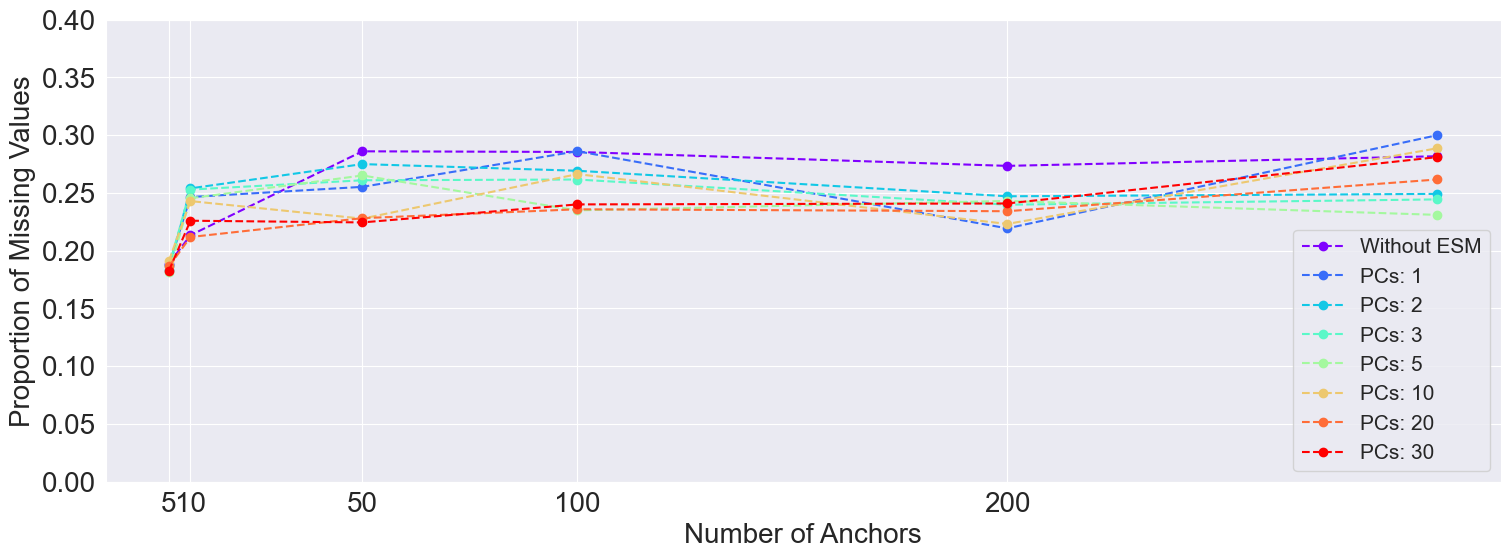

In [87]:
# x-axis: n_anchors, y-axis: fdr_conf1, group by: n_pc
unique_n_pc = df['n_pcs'].unique()
colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_pc)))

plt.figure(figsize=(18, 6))
# Specify the upper limit of FDR to view:
plt.ylim(0,0.4)

# Plot each line separately for each unique value in 'n_pc'
for i, n_pc in enumerate(unique_n_pc):
    subset_df = df[df['n_pcs'] == n_pc]
    mean_values = subset_df.groupby('n_anchors')['prop_nan_after'].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'PCs: {int(n_pc)}' if n_pc>0 else "Without ESM", color=colors[i])

plt.xlabel('Number of Anchors', fontsize=20)
plt.xticks([5,10,50,100,200], fontsize=20)
plt.yticks(fontsize=20)
plt.ylabel('Proportion of Missing Values', fontsize=20)
plt.legend(fontsize=15)

plt.show()

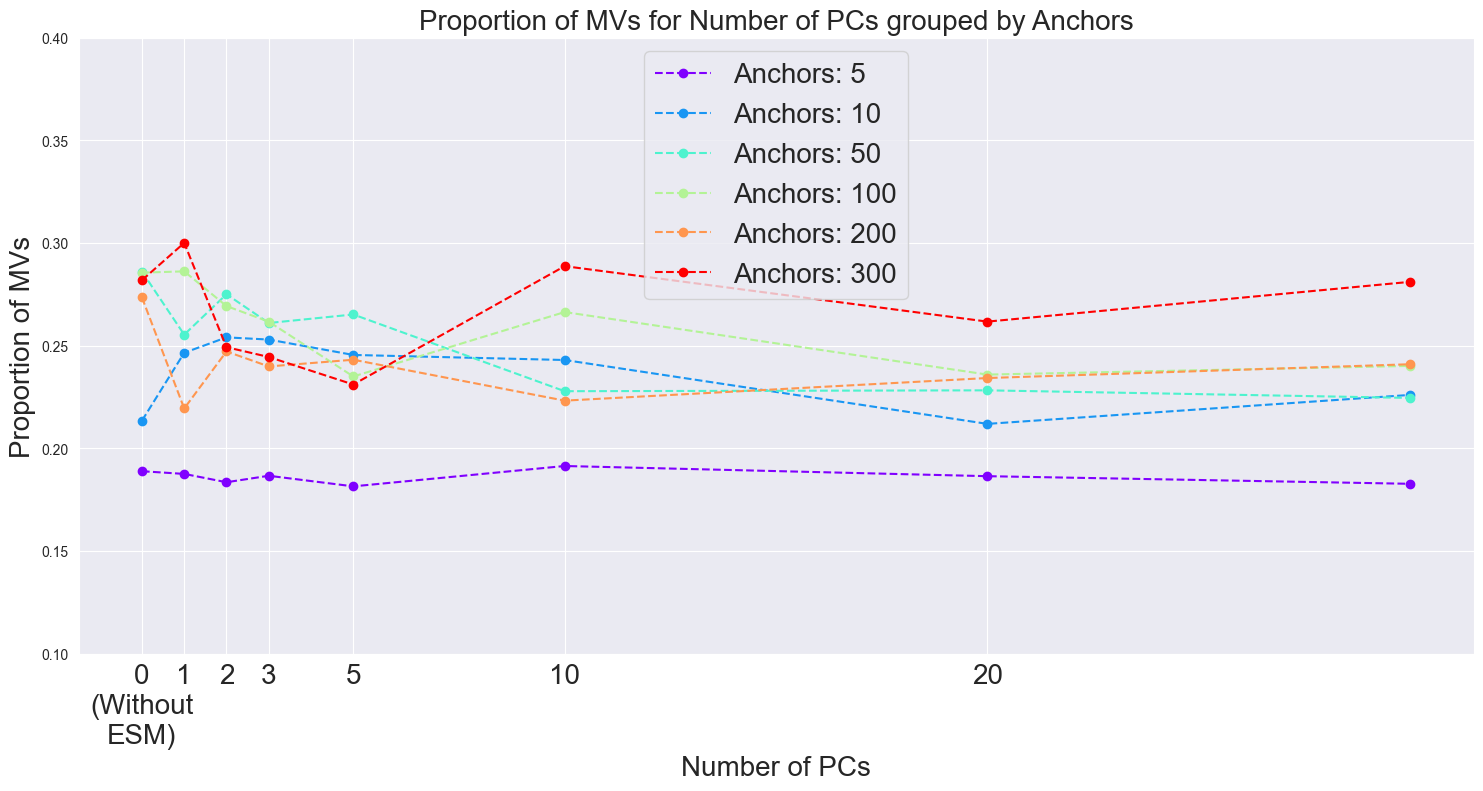

In [88]:
# x-axis: n_pc, y-axis: fdr_conf1, group by: n_anchors
unique_n_anchors = df['n_anchors'].unique()

colors = plt.cm.rainbow(np.linspace(0, 1, len(unique_n_anchors)))

plt.figure(figsize=(18, 8))
# Specify the upper limit of FDR to view:
plt.ylim(0.1,0.4)


# Plot each line separately for each unique value in 'n_pc'
for i, n_anchor in enumerate(unique_n_anchors):
    subset_df = df[df['n_anchors'] == n_anchor]
    mean_values = subset_df.groupby('n_pcs')['prop_nan_after'].mean()
    plt.plot(mean_values.index, mean_values.values, marker='o', linestyle='--',
             label=f'Anchors: {int(n_anchor)}', color=colors[i])

plt.xlabel('Number of PCs', fontsize=20)
plt.xticks([0,1,2,3,5,10,20], ['0\n(Without\nESM)',1,2,3,5,10,20], fontsize=20) # ,2,5,10
plt.ylabel('Proportion of MVs', fontsize=20)
plt.title('Proportion of MVs for Number of PCs grouped by Anchors', fontsize=20)
plt.legend(fontsize=20)

plt.show()

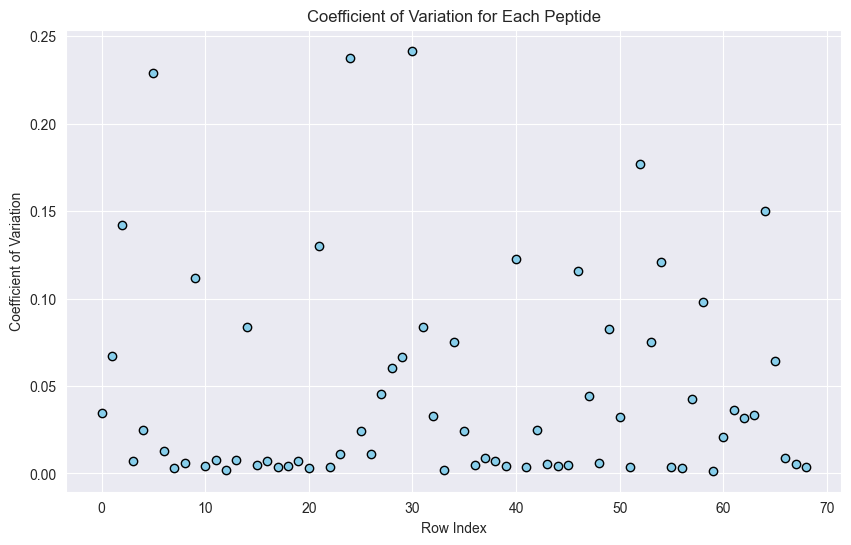

In [89]:
# Log2 before CV calculation
expression_fill_log2 = np.log2(expression_fill)  

# Calculate the coefficient of variation for each row
cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))

# Create a dot plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=np.arange(len(cv_values)), y=cv_values, color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel('Row Index')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Coefficient of Variation for Each Peptide')

plt.show()

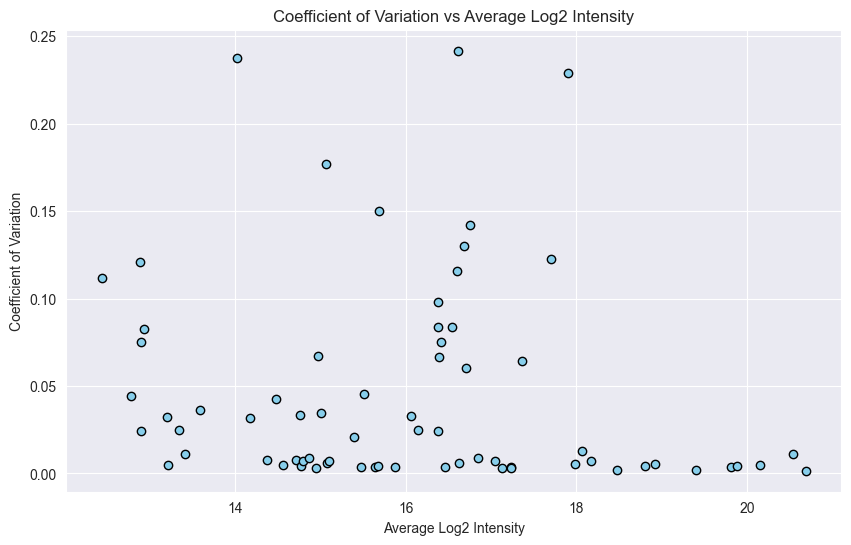

In [90]:
# Log2 before CV calculation
expression_fill_log2 = np.log2(expression_fill)     

# Average Log2 intensity per row/peptide
log2_mean_per_peptide = expression_fill_log2.mean(axis=1)

# Calculate the coefficient of variation for each row
cv_values = (expression_fill_log2.std(axis=1) / expression_fill_log2.mean(axis=1))

cv_vs_log2 = pd.concat([log2_mean_per_peptide, cv_values], axis=1)

cv_vs_log2.columns = ['Log2', 'CV']

# Sort according to log2 intensity
cv_vs_log2 = cv_vs_log2.sort_values(by='Log2')

# Create a dot plot
fig, ax = plt.subplots(figsize=(10, 6))
ax.scatter(x=cv_vs_log2['Log2'], y=cv_vs_log2['CV'], color='skyblue', edgecolor='black')

# Set labels and title
ax.set_xlabel('Average Log2 Intensity')
ax.set_ylabel('Coefficient of Variation')
ax.set_title('Coefficient of Variation vs Average Log2 Intensity')

plt.show()

Let's compute the coefficient of variance for each peptide and plot it with the mean.

In [91]:
expression_cv_features = expression_features[['PrecursorID', 'Intensities']].copy()
expression_cv_features['Intensities'] = np.log2(expression_cv_features['Intensities'] + 1)

expression_cv_features = expression_cv_features.groupby('PrecursorID').agg(['mean', 'std'])
expression_cv_features['CV'] = expression_cv_features['Intensities']['std'] / expression_cv_features['Intensities']['mean']
expression_cv_features['CV2'] = expression_cv_features['CV'] ** 2

In [92]:
n = 10_000
random_indices = np.random.choice(range(len(expression_cv_features)), size=n, replace=False)

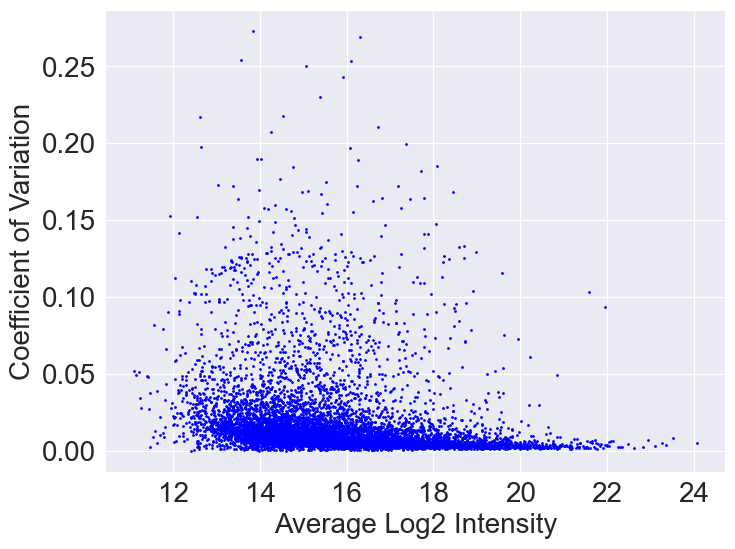

In [93]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(expression_cv_features['Intensities']['mean'].iloc[random_indices], expression_cv_features['CV'].iloc[random_indices], s=1, color='blue')
ax.set_xlabel('Average Log2 Intensity', fontsize=20)
#ax.set_ylabel('CV²', fontsize=20)
ax.set_ylabel('Coefficient of Variation', fontsize=20)
plt.xticks(fontsize=20)
plt.yticks(fontsize=20)
# ax.set_title('Log Expression | Intensity: CV² vs Mean')
ax.grid(True)
ax.set_axisbelow(True)

### Identification on held-out MS2 run

Let's hold out all the peptides in the MS2 dataset for a specific run and see how many of them are identified.

In [ ]:
runs = ms1_data['Raw file'].unique()

run_to_benchmark = runs[0]
print('Run to benchmark: {}'.format(run_to_benchmark))

other_runs = runs[runs != run_to_benchmark]

ms2_data_subset = ms2_data[ms2_data['Raw file'] != run_to_benchmark]
ms2_embeddings_subset = ms2_embeddings[ms2_data['Raw file'] != run_to_benchmark]

ms2_data_benchmark = ms2_data[ms2_data['Raw file'] == run_to_benchmark].copy()
ms2_embeddings_benchmark = ms2_embeddings[ms2_data['Raw file'] == run_to_benchmark]

In [ ]:
k = 15

identities, confidence = model.propagate(ms2_data_benchmark, ms2_data_subset, k_neighbours=k)

In [ ]:
print(f"Number of prototypes: {ms2_data_subset['PrecursorID'].nunique()}")

In [ ]:
ms2_data_benchmark['Identification'] = identities
ms2_data_benchmark['Identification Confidence'] = confidence

Let's plot the distribution of the confidence scores for the MS2 identifications. Additionally, we'll add a threshold to the plot, which we'll use to filter out low confidence identifications.

In [ ]:
peptide_threshold = 0.2


fig, ax = plt.subplots(figsize=(8, 6))
ax.hist(ms2_data_benchmark['Identification Confidence'], bins=80, color='blue', edgecolor='black', linewidth=1.2)
ax.set_xlabel('Confidence')
ax.set_ylabel('Number of peptides')
ax.set_title(f'Distribution of peptide confidence - knn={k}')
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)

ax.axvline(x=peptide_threshold, color='red', linestyle='--')
ax.axvline(x=1/k, color='black', linestyle='--')
ax.axvspan(peptide_threshold, 1, alpha=0.1, color='red')

benchmark_threshold = ms2_data_benchmark[ms2_data_benchmark['Identification Confidence'] > peptide_threshold]
matches = np.sum(benchmark_threshold['PrecursorID'] == benchmark_threshold['Identification'])

identified_count = np.sum(ms2_data_benchmark['Identification Confidence'] > peptide_threshold)
ax.text(peptide_threshold + 0.01, 5000, f'Peptides identified correctly: {matches} ({matches / benchmark_threshold.shape[0] * 100:.2f}%)', color='red')

Let's plot the number of peptides identified correctly for different thresholds.

In [ ]:
thresholds = np.linspace(1/k*2, 1, 50)
identified_counts = []
correct_counts = []

for threshold in thresholds:
    benchmark_threshold = ms2_data_benchmark[ms2_data_benchmark['Identification Confidence'] > threshold]
    matches = np.sum(benchmark_threshold['PrecursorID'] == benchmark_threshold['Identification'])
    identified_counts.append(benchmark_threshold.shape[0])
    correct_counts.append(matches)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(thresholds, identified_counts, color='red', linewidth=1.2, label='Identified peptides')
ax.plot(thresholds, correct_counts, color='blue', linewidth=1.2, linestyle='--', label='Correctly identified peptides')
ax.set_xlabel('Confidence threshold')
ax.set_ylabel('Number of peptides')
ax.set_title(f'Number of peptides identified correctly as a function of confidence threshold - knn={k}')
ax.set_xlim([0, 1])
ax.grid(True)
ax.set_axisbelow(True)
ax.legend()